In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

In [10]:
# 1. 準備資料 (抓取近 2 年資料，樣本數比較夠)
stock_id = "2330.TW"
print(f"機器人正在進行嚴格回測：{stock_id} ...")
stock = yf.Ticker(stock_id)
df = stock.history(period="2y")

機器人正在進行嚴格回測：2330.TW ...


In [11]:
# 2. 計算技術指標
# A. 均線 (MA)
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# B. RSI 強弱指標 (14天) - 這是標準算法
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).fillna(0)
loss = (-delta.where(delta < 0, 0)).fillna(0)
# 使用 Wilder's Smoothing (一般軟體的標準)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

In [12]:
# 3. 定義策略訊號
# 取得昨天的數據
df['Prev_MA5'] = df['MA5'].shift(1)
df['Prev_MA20'] = df['MA20'].shift(1)

# 訊號 1: 黃金交叉 (MA5 > MA20)
golden_cross = (df['MA5'] > df['MA20']) & (df['Prev_MA5'] < df['Prev_MA20'])

# 訊號 2: RSI 濾網 (RSI < 70 才准買，避免追高)
rsi_safe = df['RSI'] < 70

# 綜合買進條件：黃金交叉 AND 沒過熱
df['Buy_Signal'] = golden_cross & rsi_safe

# 賣出條件：死亡交叉 (MA5 < MA20) - 逃命要緊，不管 RSI
df['Sell_Signal'] = (df['MA5'] < df['MA20']) & (df['Prev_MA5'] > df['Prev_MA20'])

In [ ]:
# 4. 回測引擎 (含成本計算)
position = 0      # 持倉 (0/1)
entry_price = 0   # 進場價
gross_profit = 0  # 帳面獲利 (不含稅費)
net_profit = 0    # 淨利 (含稅費)
trade_count = 0   # 交易次數
logs = []         # 交易紀錄

# 設定成本費率
FEE_RATE = 0.001425 # 手續費 0.1425%
TAX_RATE = 0.003    # 證交稅 0.3%


日期           動作     價格         RSI      成本/損益(含稅)
------------------------------------------------------------


In [ ]:
print(f"\n{'日期':<12} {'動作':<6} {'價格':<10} {'RSI':<8} {'成本/損益(含稅)'}")
print("-" * 60)

for index, row in df.iterrows():
    # 進場邏輯
    if position == 0 and row['Buy_Signal']:
        position = 1
        entry_price = row['Close']
        
        # 計算買進成本 (股價 + 手續費)
        cost = entry_price * (1 + FEE_RATE)
        
        trade_count += 1
        logs.append({'Date': index, 'Action': 'Buy', 'Price': entry_price, 'RSI': row['RSI']})
        print(f"{index.strftime('%Y-%m-%d'):<12} 🔴買進   {entry_price:<10.2f} {row['RSI']:<8.1f} (手續費: {entry_price*FEE_RATE:.1f})")

    # 出場邏輯
    elif position == 1 and row['Sell_Signal']:
        position = 0
        exit_price = row['Close']
        
        # 計算賣出實拿 (股價 - 手續費 - 證交稅)
        revenue = exit_price * (1 - FEE_RATE - TAX_RATE)
        buy_cost = entry_price * (1 + FEE_RATE)
        
        # 單筆損益
        trade_profit_net = revenue - buy_cost
        trade_profit_gross = exit_price - entry_price
        
        gross_profit += trade_profit_gross
        net_profit += trade_profit_net
        
        logs.append({'Date': index, 'Action': 'Sell', 'Price': exit_price, 'Profit': trade_profit_net})
        print(f"{index.strftime('%Y-%m-%d'):<12} 🟢賣出   {exit_price:<10.2f} {row['RSI']:<8.1f} 淨利: {trade_profit_net:+.1f}")

# 強制結算
if position == 1:
    last_price = df.iloc[-1]['Close']
    revenue = last_price * (1 - FEE_RATE - TAX_RATE)
    buy_cost = entry_price * (1 + FEE_RATE)
    profit = revenue - buy_cost
    net_profit += profit
    print(f"{df.index[-1].strftime('%Y-%m-%d'):<12} 🔚結算   {last_price:<10.2f} ...      淨利: {profit:+.1f}")

2024-05-08   🔴買進   779.59     56.9     (手續費: 1.1)
2024-06-05   🟢賣出   830.13     58.0     淨利: +45.8
2024-06-06   🔴買進   869.01     66.9     (手續費: 1.2)
2024-07-22   🟢賣出   916.28     41.4     淨利: +42.0
2024-08-15   🔴買進   920.19     50.2     (手續費: 1.3)
2024-09-04   🟢賣出   867.49     37.9     淨利: -57.8
2024-09-18   🔴買進   922.33     52.4     (手續費: 1.3)
2024-11-04   🟢賣出   1019.37    54.1     淨利: +91.2
2024-11-08   🔴買進   1068.37    65.7     (手續費: 1.5)
2024-11-15   🟢賣出   1014.47    48.6     淨利: -59.9
2024-12-05   🔴買進   1053.67    60.6     (手續費: 1.5)
2025-02-14   🟢賣出   1042.96    41.9     淨利: -16.8
2025-04-29   🔴買進   891.64     50.8     (手續費: 1.3)
2025-06-02   🟢賣出   935.13     47.7     淨利: +38.1
2025-06-09   🔴買進   993.45     62.2     (手續費: 1.4)
2025-08-22   🟢賣出   1126.72    47.1     淨利: +126.9
2025-08-28   🔴買進   1151.54    51.5     (手續費: 1.6)
2025-09-02   🟢賣出   1151.54    51.4     淨利: -6.7
2025-09-09   🔴買進   1191.25    61.9     (手續費: 1.7)
2025-11-11   🟢賣出   1460.13    56.3     淨利: +260.7
2025-12-0

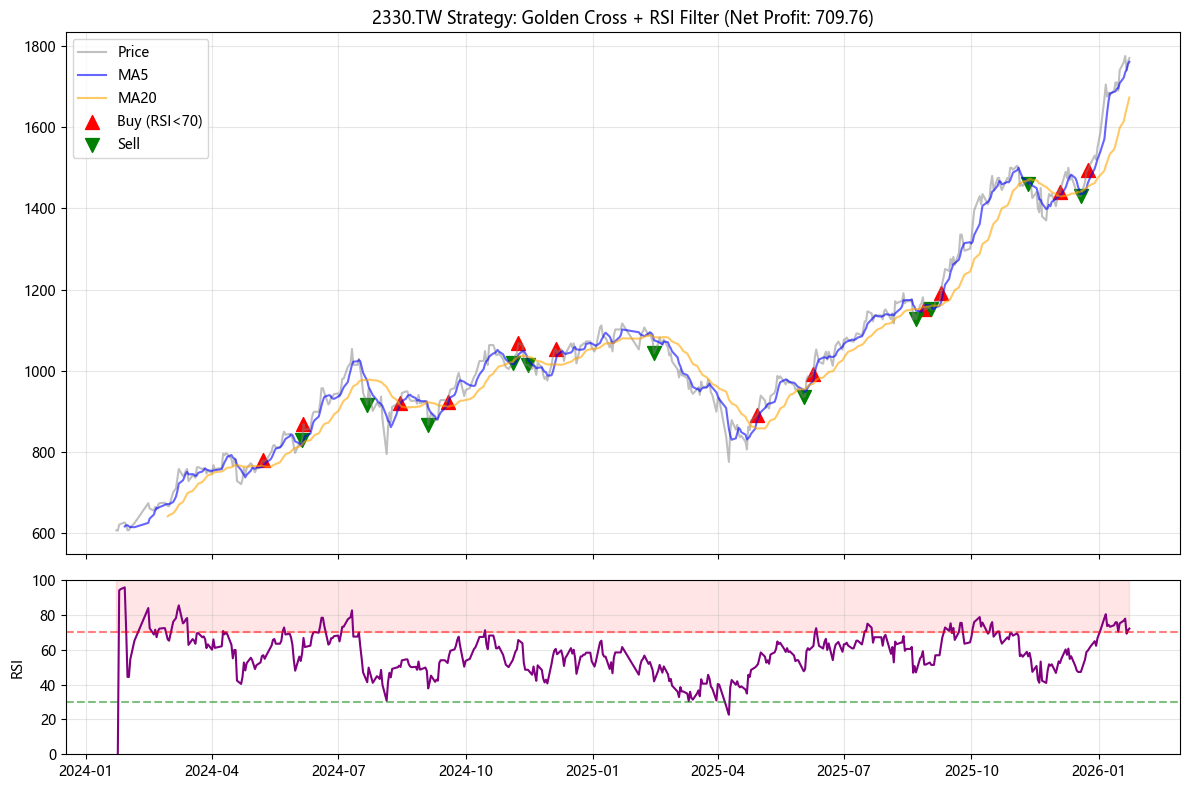

------------------------------------------------------------
交易次數: 12 次
帳面獲利 (不含稅): 512.99 元
實際淨利 (扣稅費): 709.76 元
稅費成本: -196.77 元
------------------------------------------------------------


In [15]:
# 5. 繪製圖表 (上圖股價，下圖 RSI)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 上圖：股價 + 買賣點
ax1.plot(df.index, df['Close'], color='gray', alpha=0.5, label='Price')
ax1.plot(df.index, df['MA5'], color='blue', alpha=0.6, label='MA5')
ax1.plot(df.index, df['MA20'], color='orange', alpha=0.6, label='MA20')
# 標記買點 (只標記真正有買的)
buys = pd.DataFrame([l for l in logs if l['Action'] == 'Buy']).set_index('Date')
if not buys.empty:
    ax1.scatter(buys.index, buys['Price'], color='red', marker='^', s=100, label='Buy (RSI<70)')
# 標記賣點
sells = pd.DataFrame([l for l in logs if l['Action'] == 'Sell']).set_index('Date')
if not sells.empty:
    ax1.scatter(sells.index, sells['Price'], color='green', marker='v', s=100, label='Sell')

ax1.set_title(f'{stock_id} Strategy: Golden Cross + RSI Filter (Net Profit: {net_profit:.2f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下圖：RSI
ax2.plot(df.index, df['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.fill_between(df.index, 70, 100, color='red', alpha=0.1) # 過熱區
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('rsi_cost_backtest.png')
plt.show()

print("-" * 60)
print(f"交易次數: {trade_count} 次")
print(f"帳面獲利 (不含稅): {gross_profit:.2f} 元")
print(f"實際淨利 (扣稅費): {net_profit:.2f} 元")
print(f"稅費成本: {gross_profit - net_profit:.2f} 元")
print("-" * 60)